**Identifikasi Permasalahan**: Kesulitan pengguna dalam mengenali jenis jerawat sejak gejala awal sering berujung pada pemilihan perawatan (skincare) yang salah, sehingga berisiko memperparah kondisi kulit.

**Solusi Utama**: Membangun sistem yang memadukan analisis citra dan gejala klinis untuk memberikan rekomendasi perawatan kulit yang tepat.

**Pertanyaan Bisnis yang akan dijawab**:   

1. Bagaimana distribusi jenis jerawat (comedonal, inflammatory, cyst) berdasarkan rentang usia dan sensitivitas kulit pengguna?   

2. Bahan aktif (ingredients) apa yang memiliki efektivitas tertinggi untuk masing-masing kondisi jerawat tersebut?

3. Bagaimana distribusi jenis jerawat (Comedonal, Inflammatory, Cystic) berdasarkan tipe kulit pengguna?

# **Library**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Wrangling**

## Gathering Data

In [4]:
df = pd.read_csv('dataset\Skincare Treatment Dataset.csv')
df.head()

,Age_Group,Skin_Type,Skin_Subtype,Sensitivity,Concern,Internal_Type,Ingredients,Concentrations,Effects
0,14-18,Normal,Normal to Dry,Yes,Acne,Comedonal,Zinc PCA + Benzoyl Peroxide + Salicylic Acid,0.5% + 2% + 5%,"Controls sebum production, Kills acne-causing ..."
1,14-18,Normal,Normal to Dry,Yes,Acne,Inflammatory,Zinc PCA + Benzoyl Peroxide + Niacinamide,0.5% + 5% + 1%,"Controls sebum production, Kills acne-causing ..."
2,14-18,Normal,Normal to Dry,Yes,Acne,Nodular,Zinc PCA + Azelaic Acid + Salicylic Acid,10% + 1% + 5%,"Controls sebum production, Reduces acne and im..."
3,14-18,Normal,Normal to Dry,Yes,Acne,Cystic,Benzoyl Peroxide + Niacinamide + Azelaic Acid,10% + 1% + 8%,"Kills acne-causing bacteria, Reduces inflammat..."
4,14-18,Normal,Normal to Dry,Yes,Dark Circles,Pigmented,Hyaluronic Acid + Caffeine + Vitamin C,3% + 2% + 0.5%,"Hydrates and plumps the skin, Reduces puffines..."


**Insight:**
- Menampilkan 5 kolom teratas dari dataset Skincare Treatment Dataset.csv yang diberi nama df.
- Dataset tersebut memiliki struktur kolom demografi umur (Age_Group), kondisi kulit (Skin_Type, Sensitivity), kategori masalah (Concern, Internal_Type), hingga data intervensi berupa kandungan bahan aktif (Ingredients) dan efek klinisnya (Effects).

## Assesing Data

In [5]:
print("\n ==================== Data type: ====================")
print(df.info())

print("\n ==================== Missing Values: ====================")
print(df.isna().sum())

print("\n ==================== Duplicate Data: ====================")
print(df.duplicated().sum())


 ==================== Data type: ====================
<class 'pandas.DataFrame'>
RangeIndex: 1120 entries, 0 to 1119
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age_Group       1120 non-null   str  
 1   Skin_Type       1120 non-null   str  
 2   Skin_Subtype    1120 non-null   str  
 3   Sensitivity     1120 non-null   str  
 4   Concern         1120 non-null   str  
 5   Internal_Type   1120 non-null   str  
 6   Ingredients     1120 non-null   str  
 7   Concentrations  1120 non-null   str  
 8   Effects         1120 non-null   str  
dtypes: str(9)
memory usage: 320.3 KB
None

 ==================== Missing Values: ====================
Age_Group         0
Skin_Type         0
Skin_Subtype      0
Sensitivity       0
Concern           0
Internal_Type     0
Ingredients       0
Concentrations    0
Effects           0
dtype: int64

 ==================== Duplicate Data: ====================
0


**Insight:**
- Hasil inspeksi awal menunjukkan bahwa dataset memiliki kualitas yang sangat baik. Terdapat 1.120 baris data tanpa ada nilai kosong (Missing Values: 0 di seluruh kolom) dan tidak ditemukan data yang terduplikasi (Duplicate Data: 0).

## Cleaning Data

In [6]:
# Filtering: Hanya mengambil 'Comedonal', 'Inflammatory', dan 'Cystic' pada kolom Internal_Type
target_acne = ['Comedonal', 'Inflammatory', 'Cystic']
df_clean = df[df['Internal_Type'].isin(target_acne)].copy()

# Mapping: Menyesuaikan nama, mengubah 'Cystic' menjadi 'Cyst'
mapping_jerawat = {
    'Comedonal': 'Comedonal',
    'Inflammatory': 'Inflammatory',
    'Cystic': 'Cyst'
}

df_clean['Internal_Type'] = df_clean['Internal_Type'].map(mapping_jerawat)

In [7]:
print("\n ==================== Dataset Skincare Treatment Dataset setelah dilakukan Cleaning ====================")
print(df_clean.head())

print("\n ==================== Data type: ====================")
print(df_clean.info())


 ==================== Dataset Skincare Treatment Dataset setelah dilakukan Cleaning ====================
   Age_Group Skin_Type   Skin_Subtype Sensitivity Concern Internal_Type  \
0      14-18    Normal  Normal to Dry         Yes    Acne     Comedonal   
1      14-18    Normal  Normal to Dry         Yes    Acne  Inflammatory   
3      14-18    Normal  Normal to Dry         Yes    Acne          Cyst   
14     14-18    Normal  Normal to Dry          No    Acne     Comedonal   
15     14-18    Normal  Normal to Dry          No    Acne  Inflammatory   

                                         Ingredients   Concentrations  \
0       Zinc PCA + Benzoyl Peroxide + Salicylic Acid   0.5% + 2% + 5%   
1          Zinc PCA + Benzoyl Peroxide + Niacinamide   0.5% + 5% + 1%   
3      Benzoyl Peroxide + Niacinamide + Azelaic Acid    10% + 1% + 8%   
14  Green Tea Extract + Salicylic Acid + Niacinamide  1% + 0.5% + 10%   
15      Salicylic Acid + Benzoyl Peroxide + Zinc PCA    3% + 2% + 10%   

    

**Insight:**
- Proses cleaning dan filtering berhasil mereduksi dataset dari 1.120 baris menjadi 240. Reduksi ini hasil dari pemfilteran pada Internal_Type kedalam 3 kelas utama (Comedonal, Inflammatory, Cyst).

# **Feature Engineering** (Side Quest)

In [8]:
# Memecah 'Ingredients' menjadi List, untuk mempermudah analisis
df_clean['Ingredients_List'] = df_clean['Ingredients'].astype(str).str.split(r'\s*\+\s*')

# Membuat kolom tipe dan sensitivitas kulit pengguna, bernama Skin Profile (Menggabungkan Skin Type & Sensitivity)
df_clean['Skin_Sensitivity'] = df_clean['Skin_Type'] + " - " + df_clean['Sensitivity'] + " (Sensitive)"

df_clean['Skin_Sensitivity'] = df_clean['Skin_Sensitivity'].str.replace(r'No \(Sensitive\)', 'Non-Sensitive', regex=True)
df_clean['Skin_Sensitivity'] = df_clean['Skin_Sensitivity'].str.replace(r'Yes \(Sensitive\)', 'Sensitive', regex=True)

# Menyiapkan Recommendation_Key
df_clean['Skin_Profile'] = df_clean['Internal_Type'] + "_" + df_clean['Skin_Type'].str.replace(" ", "")

df_clean.head()

,Age_Group,Skin_Type,Skin_Subtype,Sensitivity,Concern,Internal_Type,Ingredients,Concentrations,Effects,Ingredients_List,Skin_Sensitivity,Skin_Profile
0,14-18,Normal,Normal to Dry,Yes,Acne,Comedonal,Zinc PCA + Benzoyl Peroxide + Salicylic Acid,0.5% + 2% + 5%,"Controls sebum production, Kills acne-causing ...","[Zinc PCA, Benzoyl Peroxide, Salicylic Acid]",Normal - Sensitive,Comedonal_Normal
1,14-18,Normal,Normal to Dry,Yes,Acne,Inflammatory,Zinc PCA + Benzoyl Peroxide + Niacinamide,0.5% + 5% + 1%,"Controls sebum production, Kills acne-causing ...","[Zinc PCA, Benzoyl Peroxide, Niacinamide]",Normal - Sensitive,Inflammatory_Normal
3,14-18,Normal,Normal to Dry,Yes,Acne,Cyst,Benzoyl Peroxide + Niacinamide + Azelaic Acid,10% + 1% + 8%,"Kills acne-causing bacteria, Reduces inflammat...","[Benzoyl Peroxide, Niacinamide, Azelaic Acid]",Normal - Sensitive,Cyst_Normal
14,14-18,Normal,Normal to Dry,No,Acne,Comedonal,Green Tea Extract + Salicylic Acid + Niacinamide,1% + 0.5% + 10%,Provides antioxidant and anti-inflammatory ben...,"[Green Tea Extract, Salicylic Acid, Niacinamide]",Normal - Non-Sensitive,Comedonal_Normal
15,14-18,Normal,Normal to Dry,No,Acne,Inflammatory,Salicylic Acid + Benzoyl Peroxide + Zinc PCA,3% + 2% + 10%,"Unclogs pores and removes excess oil, Kills ac...","[Salicylic Acid, Benzoyl Peroxide, Zinc PCA]",Normal - Non-Sensitive,Inflammatory_Normal


**Insight:**
- pemecahan Ingredients menjadi List (Ingredients_List) memungkinkan sistem menghitung frekuensi bahan aktif secara granular.
- Pembuatan kolom Skin_Sensitivity menyatukan parameter Skin_Type dan Sensitivity, guna mempermudah pengimplementasian filtering, dibandingkan harus membuat dua logika pengecekan terpisah.
- Pembuatan kolom Skin_Profile menyatukan parameter Internal_Type dan Skin_Type, guna mempermudah pengimplementasian filtering, dibandingkan harus membuat dua logika pengecekan terpisah.

# **EDA dan Visualisasi**

**Distribusi jenis jerawat berdasarkan rentang usia dan sensitivitas kulit**

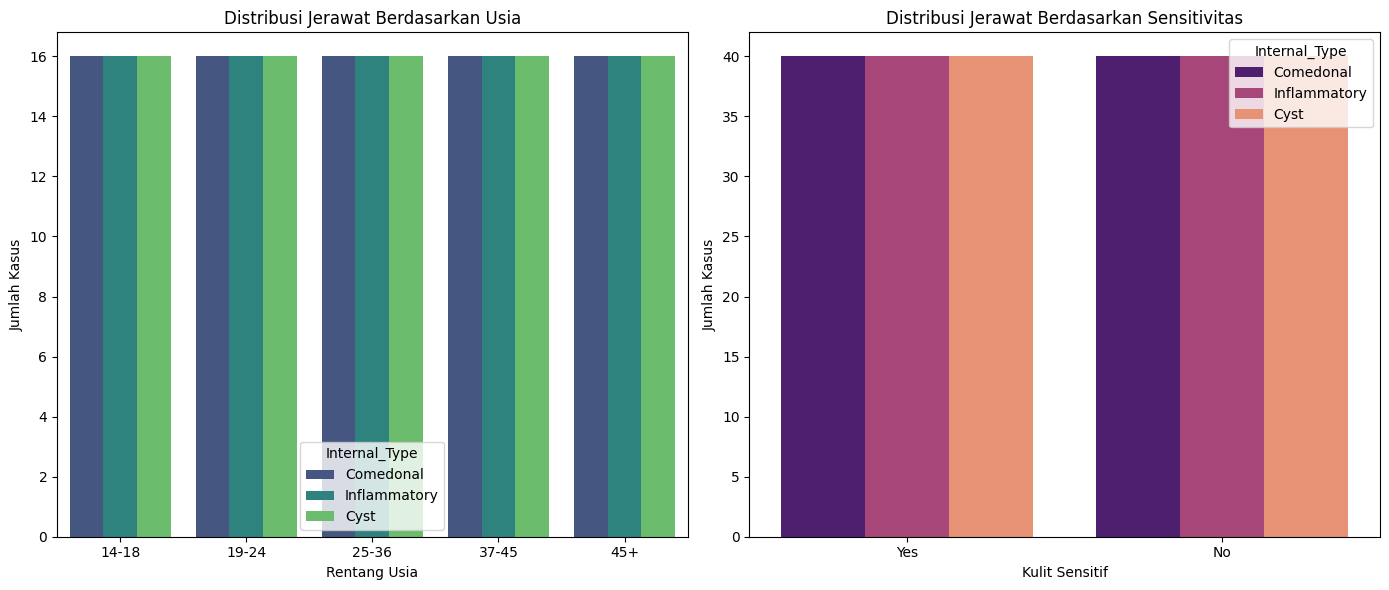

In [9]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
# Visualisasi usia vs tipe jerawat
sns.countplot(data=df_clean, x='Age_Group', hue='Internal_Type', palette='viridis')
plt.title('Distribusi Jerawat Berdasarkan Usia')
plt.xlabel('Rentang Usia')
plt.ylabel('Jumlah Kasus')

plt.subplot(1, 2, 2)
# Visualisasi sensitivitas vs tipe jerawat
sns.countplot(data=df_clean, x='Sensitivity', hue='Internal_Type', palette='magma')
plt.title('Distribusi Jerawat Berdasarkan Sensitivitas')
plt.xlabel('Kulit Sensitif')
plt.ylabel('Jumlah Kasus')
plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan visualisasi demografi, terlihat bahwa distribusi ketiga tipe jerawat tersebar secara rata dan seimbang sempurna (keseimbangan statis) pada seluruh rentang usia maupun tingkat sensitivitas kulit pengguna.

**Bahan Aktif (Ingredients) Berdasarkan Tipe Jerawat**

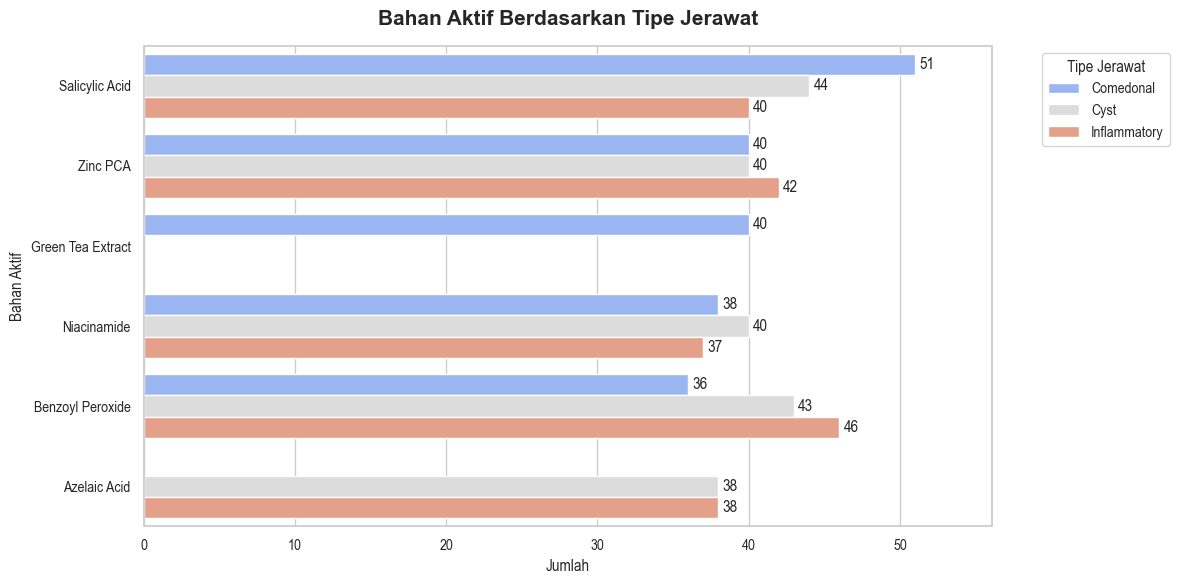

In [10]:
# Agregasi Data
top_ingredients = (
    df_clean.explode('Ingredients_List')
    .groupby('Internal_Type')['Ingredients_List']
    .value_counts()
    .groupby(level=0, group_keys=False).head(5)
    .reset_index(name='Jumlah')
)

# Visualisasi
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=top_ingredients, x='Jumlah', y='Ingredients_List', hue='Internal_Type', palette='coolwarm')

plt.title('Bahan Aktif Berdasarkan Tipe Jerawat', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Jumlah', fontsize=12)
plt.ylabel('Bahan Aktif', fontsize=12)

# Menambahkan angka pada diagram
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xlim(0, top_ingredients['Jumlah'].max() * 1.1)

plt.legend(title='Tipe Jerawat', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Insight:**
- Salicylic Acid muncul sebagai primadona perawatan dengan tingkat kemunculan tertinggi (51 kali) khusus untuk mengatasi jerawat Comedonal. Sementara itu, Benzoyl Peroxide tercatat paling dominan (46 kali) untuk menangani jerawat Inflammatory. Di sisi lain, Zinc PCA dan Green Tea Extract menunjukkan fleksibilitas tinggi karena direkomendasikan dalam jumlah yang stabil (berkisar 37-42 kali) pada hampir semua jenis jerawat, menjadikannya bahan pendukung yang sangat baik.

**Distribusi jenis jerawat berdasarkan tipe kulit**

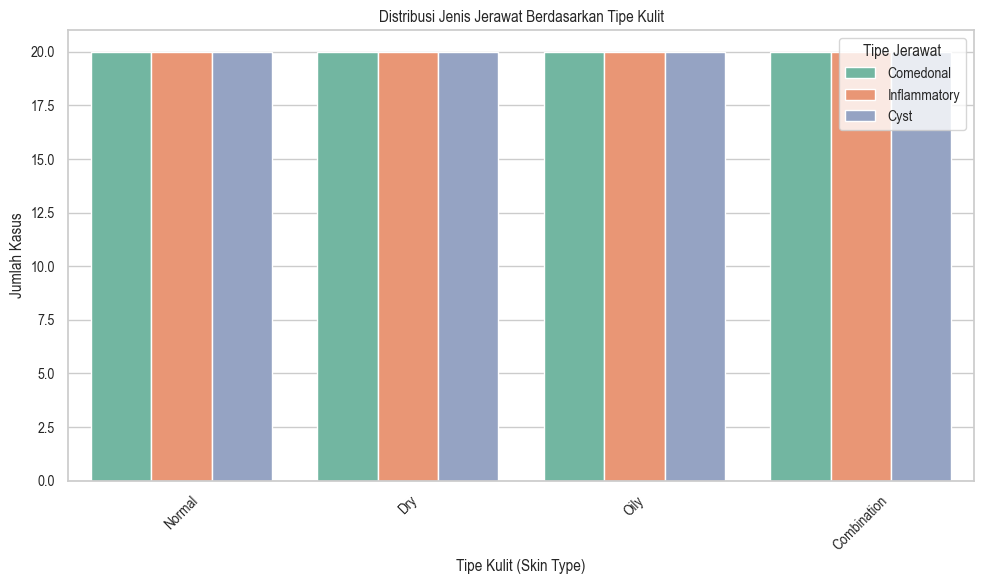

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='Skin_Type', hue='Internal_Type', palette='Set2')
plt.title('Distribusi Jenis Jerawat Berdasarkan Tipe Kulit')
plt.xlabel('Tipe Kulit (Skin Type)')
plt.ylabel('Jumlah Kasus')
plt.xticks(rotation=45)
plt.legend(title='Tipe Jerawat')
plt.tight_layout()
plt.show()

**Insight:**
- Distribusi tipe jerawat (Comedonal, Inflammatory, Cyst) pada setiap tipe kulit (Normal, Dry, Oily, Combination) menunjukkan angka yang konstan dan merata persis di angka 20 kasus untuk masing-masing kombinasi.